### Pandas e Geopandas

A biblioteca `Pandas` foi criada para ajudar na manipulação de dados, especialmente em formato tabular. `Geopandas` é uma extensão do `Pandas` projetadas para manipulação de dados geoespaciais. Ou seja, além de ser compatível com o `Pandas` na manipulação da tabela de atributos, também oferece métodos de manipulação de componentes espaciais como geometrias.

A documentação das duas bibliotecas podem sere encontradas nos seguintes links:

- Pandas > https://pandas.pydata.org/ 

- Geopandas > https://geopandas.org/en/stable/index.html

Instalando as bibliotecas:

`conda install -c conda-forge geopandas`

`conda install -c conda-forge pandas`



In [43]:
# Importando bibliotecas

import geopandas as gpd
import numpy as np
import pandas as pd


A principal estrutura dessas bibliotecas é o `DataFrame`. Essa estrutura permite armazenar informações em forma de linhas e colunas (Series). No caso, o `GeoPandas` é uma extensão do `Pandas` em que uma das colunas se refere à geometria dos objetos. Dessa forma a estrutura se torna um `GeoDataFrame`, muitas vezes apelidado na comunidade como `gdf`.

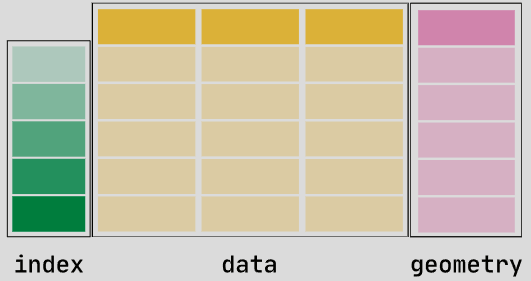

Podemos carregar arquivos vetoriais com a função `gpd.read_file()`

In [44]:
# Carregando os arquivos vetoriais
calc = gpd.read_file("C:/Users/PC/Desktop/coiso_mariane/merge_detected_18MYS.shp")
ref = gpd.read_file("C:/Users/PC/Desktop/coiso_mariane/ref_2023.shp")

In [45]:
#visualizando
calc.head()
#calc.tail()

,area_ha,RCRmin,Date,Confidence,int_area,area,Tile,Treatment,num_ovrlps,geometry
0,0.46,50.000000,3468.0,100.0,0.895533,4600.0,18MYS,T1,8,"POLYGON ((-72.31771 -7.22957, -72.31744 -7.229..."
1,0.64,47.265625,3480.0,100.0,0.000000,6400.0,18MYS,T1,5,"POLYGON ((-72.28523 -7.22929, -72.2845 -7.2292..."
2,2.12,45.929245,3192.0,100.0,1.000000,21200.0,18MYS,T1,6,"POLYGON ((-72.5853 -7.23097, -72.58313 -7.2309..."
3,0.41,57.804878,3480.0,100.0,0.000000,4100.0,18MYS,T1,6,"POLYGON ((-72.22985 -7.22949, -72.22958 -7.229..."
4,1.22,47.483607,3432.0,100.0,0.748411,12200.0,18MYS,T1,9,"POLYGON ((-72.44737 -7.23167, -72.44656 -7.231..."


In [46]:
# Resumo geral das colunas numéricas
calc.describe()


,area_ha,RCRmin,Date,Confidence,int_area,area,num_ovrlps
count,23674.000000,23674.000000,23674.000000,23674.000000,23674.000000,23674.000000,23674.000000
mean,2.034106,45.557906,3361.580975,99.833886,0.475941,20341.061924,7.668159
std,3.248894,5.201021,143.403149,0.599045,0.432434,32488.941942,2.046280
min,0.400000,32.761957,3000.000000,94.000000,0.000000,4000.000000,1.000000
25%,0.650000,41.864036,3204.000000,100.000000,0.000000,6500.000000,6.000000
50%,1.090000,45.099505,3432.000000,100.000000,0.645480,10900.000000,9.000000
75%,2.160000,48.582661,3444.000000,100.000000,0.905970,21600.000000,9.000000
max,68.470000,70.345455,3492.000000,100.000000,1.000000,684700.000000,9.000000


In [ ]:
# Consultando nomes das colunas
calc.columns

In [ ]:
# Consultando colunas 

calc['area_ha']

In [ ]:
# Consultas com expressões

calc['area_ha'] > 10

In [ ]:
calc[calc['area_ha'] > 10][['Date','area_ha','area']]

In [77]:
# Consultado colunas com loc

resultado = calc.loc[calc['area_ha'] > 10, ['Date',]]

In [ ]:
help(pd.DataFrame.loc)

In [ ]:
# Consultando linhas
calc.iloc[1:4]

In [ ]:
# Consultando uma posição específica

calc.iloc[1,2]

In [ ]:
# Iterando nas linhas de um pd.dataframe
i = 0
for idx, row in calc.iterrows():
    print(type(row))
    if i == 5:
        break
    i+=1

Para limpar o DataFrame:

- `.dropna( )` - Para remover linhas que contém células vazias;
- `.dropna(subset = 'nome_coluna')` - Para remover linhas que contém células vazias com base em uma coluna específica;
- `.fillna( ) `- Substituir valores na por outro;


RESOLVENDO PROBLEMAS REAIS:

Cálcular a área de interseção entre polígonos que possuem mais de 50% de sobreposição entre sí

In [47]:
print(f'Target: {calc.crs} \n Ref: {ref.crs}')

Target: EPSG:4326 
 Ref: EPSG:4674


In [48]:
# Verificando os CRS's reprojetando CRS com função .to_crs
ref = ref.to_crs("EPSG:31978")
calc = calc.to_crs("EPSG:31978")

In [50]:
print(f'Target: {calc.crs} \n Ref: {ref.crs}')

Target: EPSG:31978 
 Ref: EPSG:31978


In [49]:
# Corrigindo alguns problemas de geometrias

calc['geometry'] = calc.geometry.buffer(0)
ref['geometry'] = ref.geometry.buffer(0)

In [51]:
# Renomeando e criando coluna de índices para cada coluna (ainda estou verificando a questão dos índices no geopandas)

gdf1 = calc.copy()
gdf2 = ref.copy()

In [52]:
# Adicionar os índices originais como colunas
gdf1["index_gdf1"] = gdf1.index
gdf2["index_gdf2"] = gdf2.index

In [ ]:
# printando dataframe
gdf1

,area_ha,RCRmin,Date,Confidence,int_area,area,Tile,Treatment,num_ovrlps,geometry,index_gdf1
0,0.46,50.000000,3468.0,100.0,0.895533,4600.0,18MYS,T1,8,"POLYGON ((796220 9200000, 796250 9200000, 7962...",0
1,0.64,47.265625,3480.0,100.0,0.000000,6400.0,18MYS,T1,5,"POLYGON ((799810 9200010, 799890 9200010, 7998...",1
2,2.12,45.929245,3192.0,100.0,1.000000,21200.0,18MYS,T1,6,"POLYGON ((766650 9200010, 766890 9200010, 7668...",2
3,0.41,57.804878,3480.0,100.0,0.000000,4100.0,18MYS,T1,6,"POLYGON ((805930 9199950, 805960 9199950, 8059...",3
4,1.22,47.483607,3432.0,100.0,0.748411,12200.0,18MYS,T1,9,"POLYGON ((781890 9199850, 781980 9199850, 7819...",4
...,...,...,...,...,...,...,...,...,...,...,...
23669,1.68,44.732143,3432.0,100.0,0.941807,16800.0,18MYS,T9,9,"POLYGON ((738440 9090410, 738460 9090410, 7384...",23669
23670,0.92,45.271739,3444.0,100.0,0.832992,9200.0,18MYS,T9,9,"POLYGON ((700160 9090370, 700210 9090370, 7002...",23670
23671,1.13,49.265487,3468.0,100.0,0.993562,11300.0,18MYS,T9,9,"POLYGON ((738150 9090360, 738160 9090360, 7381...",23671
23672,2.14,44.359813,3444.0,100.0,0.939189,21400.0,18MYS,T9,9,"POLYGON ((703840 9090370, 703860 9090370, 7038...",23672


In [ ]:
# selecionando apenas as colunas de índice e geometria

gdf1 = gdf1[["index_gdf1","geometry"]]
gdf2 = gdf2[["index_gdf2","geometry"]]

In [ ]:
# Observando se deu certo...
gdf1

,index_gdf1,geometry
0,0,"POLYGON ((796220 9200000, 796250 9200000, 7962..."
1,1,"POLYGON ((799810 9200010, 799890 9200010, 7998..."
2,2,"POLYGON ((766650 9200010, 766890 9200010, 7668..."
3,3,"POLYGON ((805930 9199950, 805960 9199950, 8059..."
4,4,"POLYGON ((781890 9199850, 781980 9199850, 7819..."
...,...,...
23669,23669,"POLYGON ((738440 9090410, 738460 9090410, 7384..."
23670,23670,"POLYGON ((700160 9090370, 700210 9090370, 7002..."
23671,23671,"POLYGON ((738150 9090360, 738160 9090360, 7381..."
23672,23672,"POLYGON ((703840 9090370, 703860 9090370, 7038..."


In [ ]:
# Calculando a área de cada polígono
gdf1["area_1"] = gdf1.geometry.area
gdf2["area_2"] = gdf2.geometry.area

In [ ]:
# Realizar a interseção com a função overlay do geopandas
intersection = gpd.overlay(gdf1, gdf2, how="intersection")
intersection

,index_gdf1,area_1,index_gdf2,area_2,geometry
0,0,4600.000000,1335,13267.531984,"POLYGON ((796249.561 9200000, 796250 9199999.3..."
1,2,21199.999999,609,48912.694157,"POLYGON ((766890 9200010, 766890 9199970, 7668..."
2,4,12200.000000,1334,12833.419228,"POLYGON ((781980 9199800, 781988.605 9199800, ..."
3,5,10200.000000,726,11063.480509,"POLYGON ((777615.35 9199810, 777599.856 919971..."
4,9,18899.999999,1327,16280.122919,"POLYGON ((760150 9199288.654, 760142.661 91992..."
...,...,...,...,...,...
14363,23668,14500.000000,1359,32884.601779,"POLYGON ((742640 9090310, 742640 9090302.111, ..."
14364,23669,16799.999999,1371,22726.851077,"POLYGON ((738451.416 9090410, 738460 9090401.2..."
14365,23670,9200.000000,1347,14040.000156,"POLYGON ((700194.956 9090370, 700202.447 90903..."
14366,23671,11300.000000,1358,25349.456352,"POLYGON ((738160 9090350, 738190 9090350, 7381..."


In [ ]:
# Cálculo das áreas

# Calcular áreas de interseção (overlay leva as informações de todos os dataframes para o datafarame de resultado)
intersection["area_intersec"] = intersection.geometry.area
intersection


,index_gdf1,area_1,index_gdf2,area_2,geometry,area_intersec
0,0,4600.000000,1335,13267.531984,"POLYGON ((796249.561 9200000, 796250 9199999.3...",4119.450759
1,2,21199.999999,609,48912.694157,"POLYGON ((766890 9200010, 766890 9199970, 7668...",21199.999911
2,4,12200.000000,1334,12833.419228,"POLYGON ((781980 9199800, 781988.605 9199800, ...",9130.610258
3,5,10200.000000,726,11063.480509,"POLYGON ((777615.35 9199810, 777599.856 919971...",5875.625396
4,9,18899.999999,1327,16280.122919,"POLYGON ((760150 9199288.654, 760142.661 91992...",12921.148539
...,...,...,...,...,...,...
14363,23668,14500.000000,1359,32884.601779,"POLYGON ((742640 9090310, 742640 9090302.111, ...",11349.867877
14364,23669,16799.999999,1371,22726.851077,"POLYGON ((738451.416 9090410, 738460 9090401.2...",15822.350753
14365,23670,9200.000000,1347,14040.000156,"POLYGON ((700194.956 9090370, 700202.447 90903...",7663.523865
14366,23671,11300.000000,1358,25349.456352,"POLYGON ((738160 9090350, 738190 9090350, 7381...",11227.254440


In [ ]:
# CRIANDO UMA COLUNA NOVA DE PROPORÇÃO 
# escolhendo o gdf_2 como referência de comparação

intersection['prop'] = intersection['area_intersec']/intersection['area_2']
intersection

,index_gdf1,area_1,index_gdf2,area_2,geometry,area_intersec,prop
0,0,4600.000000,1335,13267.531984,"POLYGON ((796249.561 9200000, 796250 9199999.3...",4119.450759,0.310491
1,2,21199.999999,609,48912.694157,"POLYGON ((766890 9200010, 766890 9199970, 7668...",21199.999911,0.433425
2,4,12200.000000,1334,12833.419228,"POLYGON ((781980 9199800, 781988.605 9199800, ...",9130.610258,0.711471
3,5,10200.000000,726,11063.480509,"POLYGON ((777615.35 9199810, 777599.856 919971...",5875.625396,0.531083
4,9,18899.999999,1327,16280.122919,"POLYGON ((760150 9199288.654, 760142.661 91992...",12921.148539,0.793676
...,...,...,...,...,...,...,...
14363,23668,14500.000000,1359,32884.601779,"POLYGON ((742640 9090310, 742640 9090302.111, ...",11349.867877,0.345142
14364,23669,16799.999999,1371,22726.851077,"POLYGON ((738451.416 9090410, 738460 9090401.2...",15822.350753,0.696196
14365,23670,9200.000000,1347,14040.000156,"POLYGON ((700194.956 9090370, 700202.447 90903...",7663.523865,0.545835
14366,23671,11300.000000,1358,25349.456352,"POLYGON ((738160 9090350, 738190 9090350, 7381...",11227.254440,0.442899


In [ ]:
# BOTH : ÍNDICES DO GDF PRESENTES EM INTERSECTION E QUE POSSUEM > 0.5 DE SOBREPOSIÇÃO

both = intersection[intersection['prop']>= 0.5]

In [ ]:
# only_gf1: só aparecem no 1 (nao teve interseção)

only_gdf1 = gdf1[~gdf1['index_gdf1'].isin(intersection['index_gdf1'])]


In [ ]:
# only_gf2: só aparecem no 2

only_gdf2 = gdf2[~gdf2['index_gdf2'].isin(intersection['index_gdf2'])] 

In [ ]:
# res_gdf1 (teve interseção mas foi menor que 0.5)

res = intersection[intersection['prop'] < 0.5]

In [110]:
only_gdf1 = pd.concat([only_gdf1,res]).drop_duplicates(subset='id_base1')

,index_gdf1,geometry,area_1,index_gdf2,area_2,area_intersec,prop
1,1,"POLYGON ((799810 9200010, 799890 9200010, 7998...",6400.000000,NaN,NaN,NaN,NaN
3,3,"POLYGON ((805930 9199950, 805960 9199950, 8059...",4100.000000,NaN,NaN,NaN,NaN
6,6,"MULTIPOLYGON (((778380 9199530, 778420 9199530...",10600.000000,NaN,NaN,NaN,NaN
7,7,"POLYGON ((767250 9199600, 767310 9199600, 7673...",13000.000000,NaN,NaN,NaN,NaN
8,8,"POLYGON ((779510 9199450, 779550 9199450, 7795...",5000.000000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
14360,23663,"POLYGON ((738640 9090410, 738640 9090440, 7386...",4800.000000,1378.0,14587.157603,667.287818,0.045745
14361,23664,"POLYGON ((738600 9090500, 738600 9090490, 7386...",8200.000000,1378.0,14587.157603,7080.655103,0.485403
14362,23666,"POLYGON ((740140 9090550, 740140 9090540, 7401...",41499.999999,393.0,93063.400001,41166.975254,0.442354
14363,23668,"POLYGON ((742640 9090310, 742640 9090302.111, ...",14500.000000,1359.0,32884.601779,11349.867877,0.345142


In [ ]:
only_gdf2 = pd.concat([only_gdf2,res]).drop_duplicates(subset='id_base2')